# Uncommon but Powerful ML Models

These models exist beyond the mainstream sklearn toolkit. Understanding them broadens your toolkit and provides insight into the foundations of modern AI.

---

## 1. Gaussian Processes (GP)

A **Gaussian Process** is a distribution over functions. Any finite collection of function values has a joint Gaussian distribution:

$$f(x) \sim \mathcal{GP}(m(x), k(x, x'))$$

- $m(x) = \mathbb{E}[f(x)]$: mean function (often 0)
- $k(x, x') = \mathbb{E}[(f(x)-m(x))(f(x')-m(x'))]$: covariance/kernel function

### GP Regression
Given observations $y = f(X) + \epsilon$, $\epsilon \sim \mathcal{N}(0, \sigma_n^2 I)$:

Posterior mean: $\bar{f}_* = K_*^T(K + \sigma_n^2 I)^{-1}y$

Posterior variance: $\text{Var}(f_*) = K_{**} - K_*^T(K + \sigma_n^2 I)^{-1}K_*$

### Common Kernels
- **RBF/Squared Exponential**: $k(x,x') = \sigma^2 \exp\left(-\frac{||x-x'||^2}{2l^2}\right)$
- **Matérn**: $k(x,x') = \frac{2^{1-\nu}}{\Gamma(\nu)}\left(\frac{\sqrt{2\nu}r}{l}\right)^\nu K_\nu\left(\frac{\sqrt{2\nu}r}{l}\right)$
- **Periodic**: $k(x,x') = \exp\left(-\frac{2\sin^2(\pi|x-x'|/p)}{l^2}\right)$
- **Linear**: $k(x,x') = \sigma_b^2 + \sigma_v^2(x-c)(x'-c)$

**Key advantage**: Provides uncertainty estimates critical for Bayesian optimization, active learning.

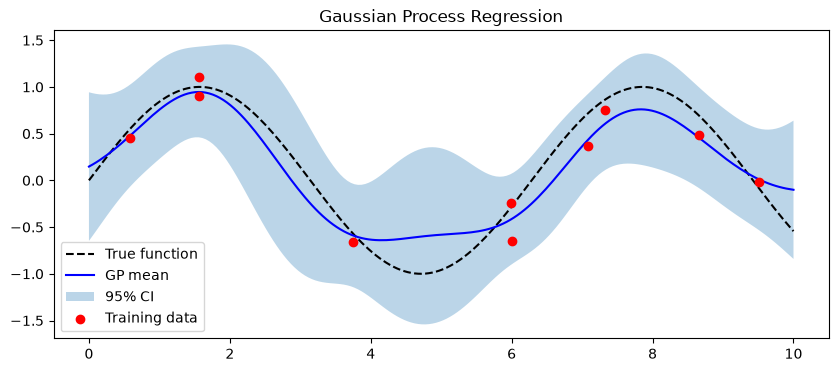

Optimized kernel: 0.599**2 * RBF(length_scale=0.971) + WhiteKernel(noise_level=0.0403)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel

# GP Regression
np.random.seed(42)
X_train = np.sort(np.random.uniform(0, 10, 10)).reshape(-1, 1)
y_train = np.sin(X_train.ravel()) + np.random.normal(0, 0.2, 10)
X_test = np.linspace(0, 10, 200).reshape(-1, 1)

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr.fit(X_train, y_train)
y_pred, y_std = gpr.predict(X_test, return_std=True)

plt.figure(figsize=(10, 4))
plt.plot(X_test, np.sin(X_test), 'k--', label='True function')
plt.plot(X_test, y_pred, 'b-', label='GP mean')
plt.fill_between(X_test.ravel(), y_pred-2*y_std, y_pred+2*y_std, alpha=0.3, label='95% CI')
plt.scatter(X_train, y_train, c='r', zorder=5, label='Training data')
plt.legend(); plt.title('Gaussian Process Regression'); plt.show()
print(f"Optimized kernel: {gpr.kernel_}")

---

## 2. Hidden Markov Models (HMM)

An HMM models sequences where the system transitions between **hidden states** generating **observable outputs**.

### Components
- **States**: $S = \{s_1, ..., s_N\}$ (hidden)
- **Observations**: $O = \{o_1, ..., o_M\}$ (visible)
- **Transition matrix**: $A_{ij} = P(q_{t+1}=s_j | q_t=s_i)$
- **Emission matrix**: $B_j(k) = P(o_t=v_k | q_t=s_j)$
- **Initial distribution**: $\pi_i = P(q_1=s_i)$

### Three Fundamental Problems
1. **Evaluation**: $P(O|\lambda)$ Forward algorithm
2. **Decoding**: Best state sequence **Viterbi algorithm**:
   $$\delta_t(i) = \max_{q_1,...,q_{t-1}} P(q_1,...,q_{t-1}, q_t=s_i, o_1,...,o_t|\lambda)$$
   Recursion: $\delta_t(j) = \max_i[\delta_{t-1}(i) a_{ij}] b_j(o_t)$
3. **Learning**: Estimate $\lambda = (A, B, \pi)$ **Baum-Welch** (EM algorithm)

In [2]:
# HMM from scratch
class HMM:
    def __init__(self, A, B, pi):
        self.A = np.array(A)   # Transition
        self.B = np.array(B)   # Emission
        self.pi = np.array(pi) # Initial
        self.N = self.A.shape[0]    # Number of states
        self.M = self.B.shape[1]    # Number of observations
    
    def viterbi(self, obs):
        T = len(obs)
        delta = np.zeros((T, self.N))
        psi = np.zeros((T, self.N), dtype=int)
        # Initialize
        delta[0] = self.pi * self.B[:, obs[0]]
        # Recursion
        for t in range(1, T):
            for j in range(self.N):
                scores = delta[t-1] * self.A[:, j]
                psi[t, j] = np.argmax(scores)
                delta[t, j] = np.max(scores) * self.B[j, obs[t]]
        # Backtrack
        states = np.zeros(T, dtype=int)
        states[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1):
            states[t] = psi[t+1, states[t+1]]
        return states, delta[-1].max()

# Example: weather HMM (Hot/Cold hidden, Low/Med/High observable)
A = [[0.7, 0.3], [0.4, 0.6]]       # Hot->Hot, Hot->Cold, Cold->Hot, Cold->Cold
B = [[0.2, 0.4, 0.4], [0.5, 0.4, 0.1]]  # Emission: Low, Med, High
pi = [0.6, 0.4]                     # Initial: P(Hot), P(Cold)
hmm = HMM(A, B, pi)
obs = [2, 2, 1, 0, 1, 2]           # High, High, Med, Low, Med, High
states, prob = hmm.viterbi(obs)
state_names = ['Hot', 'Cold']
obs_names = ['Low', 'Med', 'High']
print('Observations:', [obs_names[o] for o in obs])
print('Viterbi path:', [state_names[s] for s in states])
print(f'Best path probability: {prob:.6f}')

Observations: ['High', 'High', 'Med', 'Low', 'Med', 'High']
Viterbi path: ['Hot', 'Hot', 'Hot', 'Hot', 'Hot', 'Hot']
Best path probability: 0.000207


---

## 3. Restricted Boltzmann Machine (RBM)

A stochastic generative model with **visible** and **hidden** binary units:

$$E(v, h) = -b^T v - c^T h - v^T W h$$

Joint probability:
$$P(v, h) = \frac{1}{Z} e^{-E(v,h)}, \quad Z = \sum_{v,h} e^{-E(v,h)}$$

Conditional distributions (tractable):
$$P(h_j=1|v) = \sigma(c_j + W_j^T v)$$
$$P(v_i=1|h) = \sigma(b_i + W_i h)$$

Training via **Contrastive Divergence (CD-k)**:
$$\Delta W = \epsilon(\langle vh^T\rangle_{data} - \langle vh^T\rangle_{recon})$$

## 4. Self-Organizing Maps (SOM)

Unsupervised competitive learning that maps high-dimensional data to a 2D grid while preserving topology.

**Best Matching Unit (BMU)**: $\text{BMU} = \arg\min_k ||x - w_k||$

**Weight update**:
$$w_k(t+1) = w_k(t) + \eta(t) h(k, \text{BMU}, t)(x - w_k(t))$$

where neighborhood function: $h(k, \text{BMU}, t) = \exp\left(-\frac{d(k,\text{BMU})^2}{2\sigma(t)^2}\right)$

and $\sigma(t) = \sigma_0 \exp(-t/\tau)$ decays over time.

## 5. Hopfield Networks

Associative memory network stores patterns and retrieves them from partial/noisy input.

**Energy function**:
$$E = -\frac{1}{2}\sum_{i\neq j} w_{ij} s_i s_j + \sum_i \theta_i s_i$$

**Hebbian learning**: $w_{ij} = \frac{1}{N}\sum_\mu \xi_i^\mu \xi_j^\mu$

State update: $s_i \leftarrow \text{sign}\left(\sum_j w_{ij} s_j - \theta_i\right)$

**Storage capacity**: ~0.138N patterns for N neurons

In [3]:
# Self-Organizing Map from scratch
class SOM:
    def __init__(self, grid_h, grid_w, input_dim, n_iter=1000, lr=0.5, sigma=None):
        self.grid_h, self.grid_w = grid_h, grid_w
        self.n_iter = n_iter
        self.lr0 = lr
        self.sigma0 = sigma or max(grid_h, grid_w) / 2
        self.weights = np.random.rand(grid_h, grid_w, input_dim)
        # Grid positions
        self.positions = np.array([[i, j] for i in range(grid_h) for j in range(grid_w)])
    
    def _find_bmu(self, x):
        dists = np.linalg.norm(self.weights.reshape(-1, self.weights.shape[-1]) - x, axis=1)
        idx = np.argmin(dists)
        return idx // self.grid_w, idx % self.grid_w
    
    def fit(self, X):
        for t in range(self.n_iter):
            lr = self.lr0 * np.exp(-t / self.n_iter)
            sigma = self.sigma0 * np.exp(-t / self.n_iter)
            x = X[np.random.randint(len(X))]
            bmu_r, bmu_c = self._find_bmu(x)
            for i in range(self.grid_h):
                for j in range(self.grid_w):
                    d2 = (i - bmu_r)**2 + (j - bmu_c)**2
                    h = np.exp(-d2 / (2 * sigma**2))
                    self.weights[i, j] += lr * h * (x - self.weights[i, j])
        return self
    
    def transform(self, X):
        return np.array([self._find_bmu(x) for x in X])

# Test SOM on iris
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
iris = load_iris()
X_iris = MinMaxScaler().fit_transform(iris.data)
som = SOM(10, 10, 4, n_iter=5000)
som.fit(X_iris)
bmus = som.transform(X_iris)
print("SOM trained. BMU positions for first 5 samples:", bmus[:5])

# Hopfield Network
class HopfieldNetwork:
    def __init__(self, n):
        self.n = n
        self.W = np.zeros((n, n))
    
    def train(self, patterns):
        for p in patterns:
            self.W += np.outer(p, p)
        self.W /= self.n
        np.fill_diagonal(self.W, 0)
    
    def predict(self, x, max_iter=20):
        s = x.copy()
        for _ in range(max_iter):
            s_new = np.sign(self.W @ s)
            s_new[s_new == 0] = 1
            if np.all(s_new == s):
                break
            s = s_new
        return s

# Store and recall patterns
hn = HopfieldNetwork(n=25)
patterns = [np.array([1,-1,1,-1,1]*5), np.array([-1,1,-1,1,-1]*5)]
hn.train(patterns)
noisy = patterns[0].copy(); noisy[np.random.choice(25, 5, replace=False)] *= -1
recalled = hn.predict(noisy)
print(f"\nRecall accuracy: {np.mean(recalled == patterns[0]):.0%}")

SOM trained. BMU positions for first 5 samples:

 [[9 4]
 [9 7]
 [9 7]
 [9 7]
 [9 3]]

Recall accuracy: 100%


---

## 6. Other Uncommon Models (Overview)

### Extreme Learning Machine (ELM)
Single hidden layer network where input weights are randomly fixed only output weights are learned:
$$\hat{\beta} = H^\dagger T$$
where $H^\dagger = (H^TH)^{-1}H^T$ is the Moore-Penrose pseudoinverse. **Extremely fast training.**

### Quantile Regression
Predicts **conditional quantiles** instead of mean. Loss function for quantile $\tau$:
$$L_\tau(y, \hat{y}) = \tau \max(y-\hat{y}, 0) + (1-\tau)\max(\hat{y}-y, 0)$$

### Isotonic Regression
Fits a non-decreasing (monotone) piecewise constant function. Uses **Pool Adjacent Violators (PAV)** algorithm. Useful for probability calibration.

### Bayesian Ridge Regression
Places Gaussian prior on weights: $p(w|\alpha) = \mathcal{N}(0, \alpha^{-1}I)$. Estimates $\alpha$ and noise variance $\lambda$ from data via **evidence maximization**.

### Kernel Ridge Regression (KRR)
Ridge regression in kernel space:
$$\hat{y} = K(K + \alpha I)^{-1}y$$
where $K_{ij} = k(x_i, x_j)$. Equivalent to SVR with $\epsilon=0$.

### Relevance Vector Machine (RVM)
Bayesian analog of SVM. Automatically determines which training points are "relevant" (sparse solution) without cross-validation for $C$. Provides probabilistic outputs.

### Learning Vector Quantization (LVQ)
Prototype-based classifier. Maintains **prototype vectors** per class. Training: move winning prototype toward/away from sample depending on correctness.

### Radial Basis Function Networks (RBFN)
Two-layer network where hidden units compute:
$$\phi_j(x) = \exp\left(-\frac{||x - c_j||^2}{2\sigma_j^2}\right)$$
Output: $\hat{y} = \sum_j w_j \phi_j(x)$. Centers $c_j$ often determined by k-means.

### MARS (Multivariate Adaptive Regression Splines)
Builds flexible piecewise linear models using **hinge functions**:
$$h(x-t) = \max(0, x-t), \quad h(t-x) = \max(0, t-x)$$
Automatically finds knot locations $t$ through forward/backward selection.

### Capsule Networks (CapsNet)
Groups neurons into **capsules** that output a vector (magnitude = probability, direction = pose).
Dynamic routing: iterative agreement mechanism between lower and higher capsules.
$$v_j = \text{squash}\left(\sum_i c_{ij}\hat{u}_{j|i}\right), \quad \text{squash}(s) = \frac{||s||^2}{1+||s||^2}\frac{s}{||s||}$$

In [4]:
from sklearn.linear_model import BayesianRidge, QuantileRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.isotonic import IsotonicRegression
from sklearn.datasets import make_regression

X_reg, y_reg = make_regression(n_samples=200, n_features=10, noise=20, random_state=42)
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Bayesian Ridge
br = BayesianRidge().fit(X_tr, y_tr)
y_pred_br, y_std_br = br.predict(X_te, return_std=True)
print(f"Bayesian Ridge R²: {br.score(X_te, y_te):.4f}")
print(f"Estimated alpha (precision): {br.alpha_:.4f}, lambda: {br.lambda_:.4f}")

# Kernel Ridge Regression
krr = KernelRidge(alpha=0.1, kernel='rbf').fit(X_tr, y_tr)
print(f"Kernel Ridge R²: {krr.score(X_te, y_te):.4f}")

# Quantile Regression median (tau=0.5) and 90th percentile (tau=0.9)
qr_50 = QuantileRegressor(quantile=0.5, alpha=0.0, solver='highs').fit(X_tr, y_tr)
qr_90 = QuantileRegressor(quantile=0.9, alpha=0.0, solver='highs').fit(X_tr, y_tr)
print(f"Quantile Regression (median) score: {qr_50.score(X_te, y_te):.4f}")

# ELM from scratch
class ELM:
    def __init__(self, n_hidden=100):
        self.n_hidden = n_hidden
    
    def fit(self, X, y):
        n_input = X.shape[1]
        self.W = np.random.randn(n_input, self.n_hidden)
        self.b = np.random.randn(self.n_hidden)
        H = np.tanh(X @ self.W + self.b)
        # Moore-Penrose pseudoinverse
        self.beta = np.linalg.pinv(H) @ y
        return self
    
    def predict(self, X):
        H = np.tanh(X @ self.W + self.b)
        return H @ self.beta

elm = ELM(n_hidden=200).fit(X_tr, y_tr)
from sklearn.metrics import r2_score
print(f"ELM R²: {r2_score(y_te, elm.predict(X_te)):.4f}")

# MARS - using py-earth
try:
    from pyearth import Earth
    mars = Earth().fit(X_tr, y_tr)
    print(f"MARS R²: {mars.score(X_te, y_te):.4f}")
except ImportError:
    print("Install py-earth for MARS: pip install sklearn-contrib-py-earth")

Bayesian Ridge R²: 0.9884
Estimated alpha (precision): 0.0025, lambda: 0.0003
Kernel Ridge R²: 0.8821
Quantile Regression (median) score: 0.9874
ELM R²: 0.6709
Install py-earth for MARS: pip install sklearn-contrib-py-earth


---

## Summary Table

| Model | Type | Key Advantage | Use Case |
|-------|------|---------------|----------|
| Gaussian Process | Probabilistic | Uncertainty quantification | Small data, Bayesian optimization |
| HMM | Sequential | Explicit temporal structure | Speech, NLP sequences |
| RBM | Generative | Feature learning | Pre-training, dimensionality reduction |
| SOM | Unsupervised | Topology preservation | Visualization, clustering |
| Hopfield | Associative | Content-addressable memory | Pattern completion |
| ELM | Supervised | Extremely fast training | Real-time applications |
| KRR | Supervised | Non-linear regression | Smooth regression tasks |
| Quantile Reg | Supervised | Interval estimation | Risk, uncertainty quantification |
| MARS | Supervised | Automatic feature interactions | Tabular data |
| CapsNet | Deep | Pose/relationship modeling | Rotated objects in vision |

---

## Additional Learning Resources

### Books
- **Gaussian Processes for Machine Learning**: [http://gaussianprocess.org/gpml/](http://gaussianprocess.org/gpml/)
- **Pattern Recognition and ML** (Bishop): [https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf)

### Papers
- **ELM**: Huang et al. [https://ieeexplore.ieee.org/document/1380068](https://ieeexplore.ieee.org/document/1380068)
- **CapsNet**: Sabour et al. [https://arxiv.org/abs/1710.09829](https://arxiv.org/abs/1710.09829)
- **HMM Tutorial**: Rabiner [https://web.ece.ucsb.edu/Faculty/Rabiner/ece259/Reprints/tutorial%20on%20hmm%20and%20applications.pdf](https://web.ece.ucsb.edu/Faculty/Rabiner/ece259/Reprints/tutorial%20on%20hmm%20and%20applications.pdf)
- **RBM (Hinton)**: [https://www.cs.toronto.edu/~hinton/absps/guideTR.pdf](https://www.cs.toronto.edu/~hinton/absps/guideTR.pdf)

### Libraries
- **hmmlearn**: [https://hmmlearn.readthedocs.io/](https://hmmlearn.readthedocs.io/)
- **GPyTorch**: [https://gpytorch.ai/](https://gpytorch.ai/)
- **MiniSom**: [https://github.com/JustGlowing/minisom](https://github.com/JustGlowing/minisom)